# Сборный проект — 2: HR-аналитика

### Описание проекта  

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён.

### Цели проекта:  

Первая задача — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.  
  
Вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

### Импорт библиотек

In [ ]:
!pip install shap -q
!pip install scikit-learn==1.6.1 -q
!pip install phik -q
import phik
from phik import report
import shap
import pandas as pd
import numpy as np
from scipy import stats as st
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV
    )
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    MinMaxScaler,
    LabelEncoder
    )
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import (DecisionTreeRegressor, DecisionTreeClassifier)
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer
from IPython.display import Markdown, display
import ipywidgets as widgets
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Задача 1. Предсказание уровня удовлетворённости сотрудника

### Описание данных  

- **id** — уникальный идентификатор сотрудника;
- **dept** — отдел, в котором работает сотрудник;
- **level** — уровень занимаемой должности;
- **workload** — уровень загруженности сотрудника;
- **employment_years** — длительность работы в компании (в годах);
- **last_year_promo** — показывает, было ли повышение за последний год;
- **last_year_violations** — показывает, нарушал ли сотрудник трудовой договор за последний год;
- **supervisor_evaluation** — оценка качества работы сотрудника, которую дал руководитель;
- **salary** — ежемесячная зарплата сотрудника;
- **job_satisfaction_rate** — уровень удовлетворённости сотрудника работой в компании, целевой признак.

### План выполнения задачи:  
   
**Шаг 1.** Загрузка и изучение данных  
**Шаг 2.** Предобработка данных  
**Шаг 3.** Исследовательский анализ данных  
**Шаг 4.** Подготовка данных  
**Шаг 5.** Обучение моделей  
**Шаг 6.** Вывод по задаче  

## Шаг 1. Загрузка и изучение данных

In [ ]:
train = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
test_features = pd.read_csv('/datasets/test_features.csv')
test_target = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

In [ ]:
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [ ]:
test_features.info()
test_features.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [ ]:
test_target.info()
test_target.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


- В train_job и test_features присутствуют пропуски столбцах: dept и level;
- Типы данных во всех таблицах соответствуют.

## Шаг 2. Предобработка данных

### Обработка дубликатов

Сначала проверим неявные дубликаты

In [ ]:
display(train['dept'].unique())
test_features['dept'].unique()

array(['sales', 'hr', 'technology', 'purchasing', 'marketing', nan],
      dtype=object)

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan, ' '],
      dtype=object)

In [ ]:
display(train['level'].unique())
test_features['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [ ]:
display(train['workload'].unique())
test_features['workload'].unique()

array(['medium', 'high', 'low'], dtype=object)

array(['medium', 'low', 'high', ' '], dtype=object)

Заменим пробелы на NaN

In [ ]:
test_features = test_features.replace(' ', np.nan)
display(test_features['dept'].unique())
test_features['workload'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan],
      dtype=object)

array(['medium', 'low', 'high', nan], dtype=object)

Теперь проверим полные дубликаты

In [ ]:
for name in [train, test_features, test_target]:
    print(name.duplicated().sum())

0
0
0


- Дубликаты в данных не обнаружены;  
- Пропуски позже обработаем в пайплайне.

## Шаг 3. Исследовательский анализ данных

In [ ]:
def analysis_num_features(df):
    for column in df.select_dtypes(include=['int64', 'float64']).columns.tolist()[1:]:
        display(Markdown(f"<center><strong>{column}</strong></center>"))
        display(df[column].describe().round(2))

        sns.set(rc={"figure.figsize": (20, 5)}) # Настройка размера фигуры
        fig, axes = plt.subplots(1, 2)

        stat, p_value = stats.shapiro(df[column].dropna()) # Проверка на нормальность
        norm = "нормальное" if p_value > 0.05 else "ненормальное"

        if df[column].nunique() <= 10: # Построение графиков в зависимости от типа признака
            sns.countplot(
                x=column,
                data=df,
                ax=axes[0],
                color='olive',
                edgecolor='black',
                linewidth=2
            )
            axes[0].set(ylabel='Количество', xlabel=column)
        else:
            sns.histplot(
                df[column],
                bins=20,
                ax=axes[0],
                color='olive',
                edgecolor='black',
                linewidth=2
            )
            axes[0].set(ylabel='Частота', xlabel=column)

        box = sns.boxplot(
            df[column],
            ax=axes[1],
            color='olive',
            linewidth=2,
            flierprops={
                'markerfacecolor': 'olive',
                'markeredgecolor': 'black',
                'markersize': 10
            }
        )
        axes[1]

        for ax in axes:
            ax.grid(True, linestyle='--', color='k', alpha=0.9)
            ax.tick_params(axis='both', labelsize=25)
            ax.xaxis.label.set_size(25)
            ax.yaxis.label.set_size(25)
            ax.title.set_size(25)

        plt.tight_layout()
        plt.show()

        display(Markdown(f"**p-value** = {p_value:.3e}, следовательно распределение **{norm}**"))
        display(Markdown((f"<center>**************************************************************************</center>")))

In [ ]:
#функция анализа категорианальных признаков
def bar_chart(df, cat_columns,  name):

    display(Markdown(f"<center>Визуализация признаков для <strong>{name}</strong></center>"))

    OLIVE_PALETTE = [
        '#808000',  # основной оливковый
        '#556B2F',  # тёмно-оливковый
        '#6B8E23',  # olivedrab
        '#BDB76B',  # darkkhaki
        '#9ACD32',  # yellowgreen
        '#F0E68C',  # khaki (светлый)
        '#8FBC8F',  # darkseagreen
    ]

    n = len(cat_columns)
    plt.figure(figsize=(5*n, 7))
    i = 1

    for column in cat_columns:
        value_counts = df[column].value_counts()

        ax = plt.subplot(1, n, i)
        i += 1

        bars = plt.bar(
                       x=value_counts.index,
                       height=value_counts.values,
                       color=OLIVE_PALETTE[:len(value_counts)],
                       edgecolor='black',
                       linewidth=1.5
                       )

        for bar in bars:
            height = bar.get_height()
            plt.text(
                    x=bar.get_x() + bar.get_width() / 2,
                    y=height + 0.01 * max(value_counts.values),
                    s=f'{height/len(df)*100:.1f}%',
                    ha='center',
                    va='bottom',
                    fontsize=15,
                    fontweight='bold'
                    )

        plt.title(column, fontsize=20, fontweight='bold')
        plt.xlabel('Категория', fontsize=15)
        plt.ylabel('Количество', fontsize=15)
        plt.xticks(rotation=45, ha='right', fontsize=15)
        plt.yticks(fontsize=15)
        plt.grid(axis='y', color='k', alpha=0.3)

    plt.tight_layout()
    plt.show()

### Количественные признаки

In [ ]:
left = widgets.Output(layout={'width': '49%'})
right = widgets.Output(layout={'width': '49%'})
display(widgets.HBox([left, right],))

with left:
    print(f"Анализ количественых признаков \033[1mtrain:\033[0m")
    display(analysis_num_features(train))

with right:
    print(f"Анализ количественых признаков \033[1mtest_features:\033[0m")
    display(analysis_num_features(test_features))
    print(f"Анализ количественых признаков \033[1mtest_target:\033[0m")
    display(analysis_num_features(test_target))

- Сразу стоит обратить внимание, что тренировочная и тестовая выборка имеет признаки с практически одинаковым распределением, значениями среднего и наличием выбросов. Это говорит о том, что разделение проведено правильно, с учетом распределений признаков;  
- признак employment_years имеет смещенное влево распределение без выбросов;
- признак supervisor_evaluation имеет смещенное вправо распределение без выбросов;
- признак salary имеет смещенное влево распределение. Наблидаются выбросы с большими значениями, но они имеют обоснование, так как зарплата у старых сотрудников на высоких должностях может быть намного выше среднего.
- признак job_satisfaction_rate имеет ненормальное распределение без выбросов.  

### Категорианальные признаки

<center>Визуализация признаков для <strong>train</strong></center>

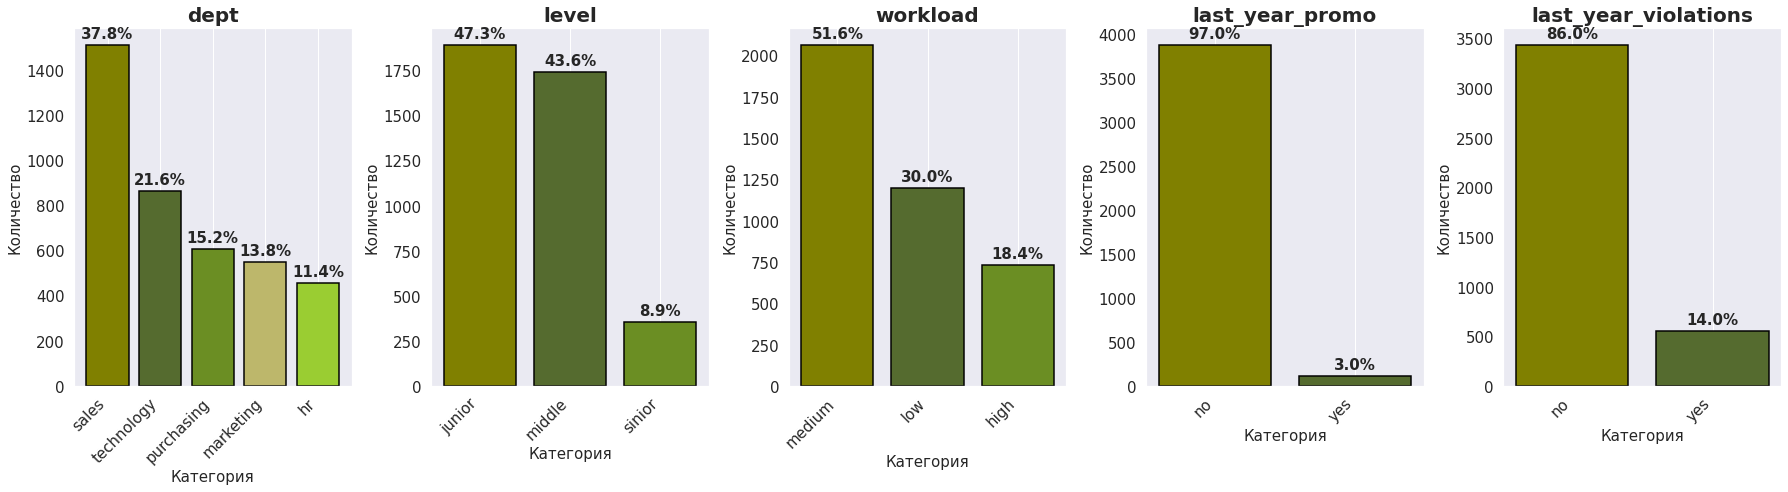

<center>Визуализация признаков для <strong>test_features</strong></center>

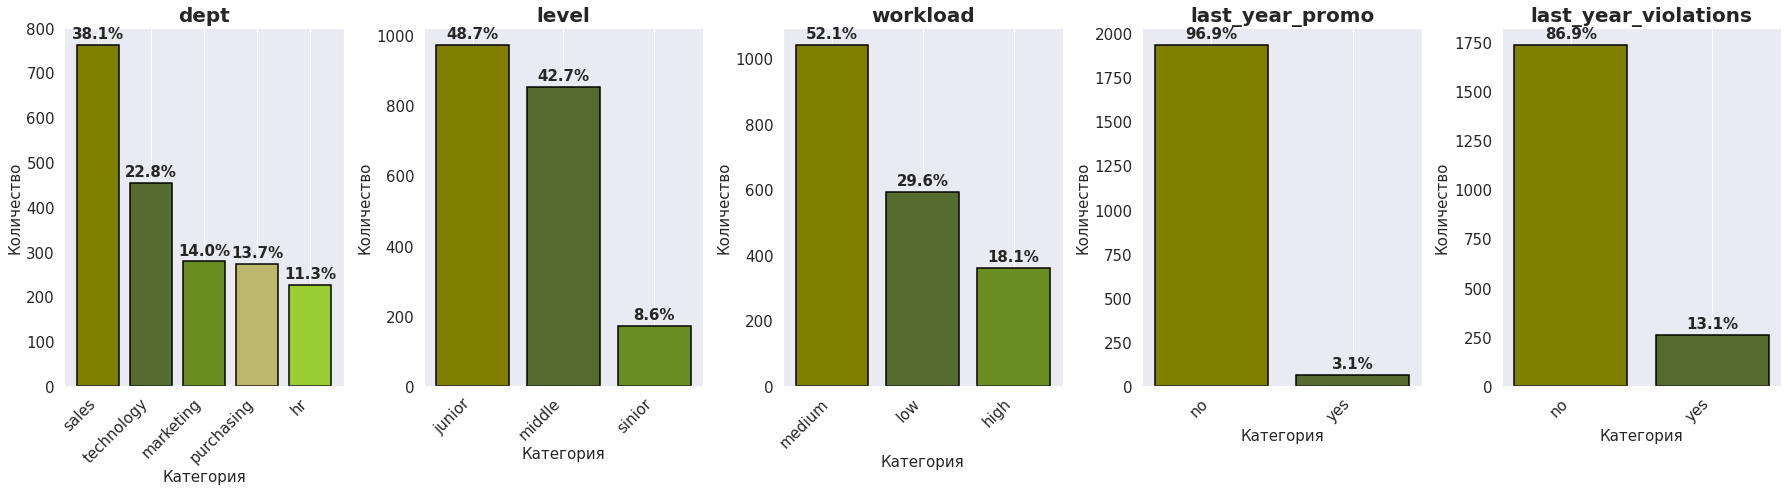

In [ ]:
bar_chart(train, train.select_dtypes(include='object').columns.tolist(), 'train')
bar_chart(test_features, test_features.select_dtypes(include='object').columns.tolist(), 'test_features')

- все категориальные признаки несбаласированны;
- необычных значений в признаках не наблюдается;
- признаки имеют схожее распределение с признаками как в тестовой, так и тренировочной выборке.

### Корреляционный анализ

Так как признаки обладают ненормальным распределением, а так же стоит вычислить корреляцию категорианальных признаков применим универсальныю phik корреляцию.

In [ ]:
left = widgets.Output(layout={'width': '49%'})
right = widgets.Output(layout={'width': '49%'})
display(widgets.HBox([left, right],))

with left:
    plt.figure(figsize=(12,10))
    heatmap = sns.heatmap(
                train[train.columns[train.columns != 'id']]\
                [list(train[train.columns[train.columns != 'id']].columns)]\
                .phik_matrix(interval_cols = [ 'salary', 'job_satisfaction_rate']),
                annot=True,
                cmap='YlGn'
                )

    heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
    heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=15)

    plt.title('Тепловая карта корреляций', fontsize=25)
    plt.show()

with right:
    plt.figure(figsize=(12,10))
    heatmap = sns.heatmap(
                test_features[test_features.columns[test_features.columns != 'id']]\
                [list(test_features[test_features.columns[test_features.columns != 'id']].columns)]\
                .phik_matrix(interval_cols = [ 'salary', 'job_satisfaction_rate']),
                annot=True,
                cmap='YlGn'
                )

    heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=15)
    heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=15)

    plt.title('Тепловая карта корреляций', fontsize=25)
    plt.show()

Имеем несколько признаков с высокой корреляцией, но ниже 0,9 отсюда делаем заключение, что мультиколлениарность отсутствует.

## Шаг 4. Подготовка данных

Добавим к тестовой выборке целевой признак

In [ ]:
test_x = test_features.copy()
test_x = test_x.merge(test_target, on='id')
test_x.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79
1,686555,hr,junior,medium,1,no,no,4,30000,0.72
2,467458,sales,middle,low,5,no,no,4,19200,0.64
3,418655,sales,middle,low,6,no,no,4,19200,0.60
4,789145,hr,middle,medium,5,no,no,5,40800,0.75


Используем пайплайн

In [ ]:
X_train = train.drop(['job_satisfaction_rate', 'id'], axis=1)

In [ ]:
y_train = train['job_satisfaction_rate']
X_test = test_x.drop(['job_satisfaction_rate', 'id'], axis=1)
y_test = test_x['job_satisfaction_rate']

cat_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

#пайплан для категорианальных признаков
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))]
                   )

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium', 'high']
                           ],
         handle_unknown='use_encoded_value',
         unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ])

#пайплайны для числовых признаков
standard_pipe = Pipeline([
    ('simplerImputer_standard', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', StandardScaler())
])

# создание общего пайплайна для подготовки данных
data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, cat_columns),
    ('ord', ord_pipe, ord_columns),
    ('num', standard_pipe, num_columns)
], remainder='passthrough')

## Шаг 5. Обучение модели

In [ ]:
# создание итогового пайплайна
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

#Параметры для передачи GridSearchCV для поиска оптимальной модели
param_grid = [
    # LinearRegression()
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    # DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 13),
        'models__max_features': range(2, 13),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

In [ ]:
# создадим метрику для оценки модели

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

smape_scorer = make_scorer(score_func=smape, greater_is_better=False)

In [ ]:
grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    n_jobs=-1,
    cv=5,
    scoring=smape_scorer
)
display(grid_search.fit(X_train, y_train))

print('\nЛучшая модель и её параметры:\n\n', grid_search.best_params_)
print('Метрика SMAPE для лучшей модели:\n', round(-grid_search.best_score_, 2))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['dept',
                                                                          'last_year_promo',
                                                                          'last_year_violations']),
                                                                        ('ord',
                                                                         Pipeline(...
             param_grid=[{'models': [LinearRegression()],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']},
                         {'models': [DecisionTreeRegressor(random_state=42)],
                          'models__max_depth': range(2, 13),
                          'models__max_features': range(2, 13),
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']}],
             scoring=make_scorer(smape, greater_is_better=False, response_method='predict'))


Лучшая модель и её параметры:

 {'models': DecisionTreeRegressor(random_state=42), 'models__max_depth': 12, 'models__max_features': 10, 'preprocessor__num': MinMaxScaler()}
Метрика SMAPE для лучшей модели:
 15.17


In [ ]:
y_pred = grid_search.predict(X_test)
y_true = y_test
print(f'\nМетрика SMAPE на тестовой выборке:\n {round(smape(y_true, y_pred), 2)}')


Метрика SMAPE на тестовой выборке:
 14.39


SMAPE ≤ 15 на тестовой выборке, что соответствует критерию успеха, установленного в задаче.

## Шаг 6. Вывод по задаче

- Загрузили и изучили данные, получив данные о наличии пропусков.  
- Провели предобработку данных в ходе которой, все же смогли заменить пропуски в столбце level, на одно из уникальных значениий.  
- Произвели исследовательский анализ и визуализацию признаков, в ходе которого было установлено, что в данных нетнормально расспределенных признаков, категорианольные прищнаки небалансированы. Корреляционный анализ указал на отсутствие мультиколлинеарности.
- Подготовили данные.
- Нашли лучшую модель согласно рекомендованной метрики SMAPE. Ей оказалась модель DecisionTreeRegressor(random_state=42).
  
  DecisionTreeRegressor справился лучше, потому что он лучше улавливает сложные нелинейные зависимости в данных, а также хорошо работает с категориальными и порядковыми признаками, которых в конечном счете у нас оказалось больше.

# Задача 2: предсказание увольнения сотрудника из компании

### Описание данных  
  
  Входные признаки идентичны предыдущей задаче, но целевой теперь quit — увольнение сотрудника из компании.

### План выполнения задачи:  
   
**Шаг 1.** Загрузка и изучение данных  
**Шаг 2.** Предобработка данных  
**Шаг 3.** Исследовательский анализ данных  
**Шаг 4.** Добавление нового входного признака  
**Шаг 5.** Подготовка данных  
**Шаг 6.** Обучение моделей  
**Шаг 7.** Вывод по задаче

## Шаг 1. Загрузка и изучение данных

In [ ]:
train_quit = pd.read_csv('/datasets/train_quit.csv')
train_quit.info()
train_quit.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [ ]:
test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')
test_target_quit.info()
test_target_quit.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


Данные загружены и изучены, замечаний по данным нет.

## Шаг 2. Предобработка данных

### Обработка дубликатов

In [ ]:
display(train_quit['dept'].unique())
display(train_quit['level'].unique())
train_quit['workload'].unique()

array(['sales', 'purchasing', 'marketing', 'technology', 'hr'],
      dtype=object)

array(['middle', 'junior', 'sinior'], dtype=object)

array(['high', 'medium', 'low'], dtype=object)

In [ ]:
for name in [train, test_features, test_target]:
    print(name.duplicated().sum())

0
0
0


## Шаг 3. Исследовательский анализ данных

### Анализ новых данных

Пироведем исследование вновь полученных датафреймов.

<center><strong>employment_years</strong></center>

count    4000.00
mean        3.70
std         2.54
min         1.00
25%         2.00
50%         3.00
75%         6.00
max        10.00
Name: employment_years, dtype: float64

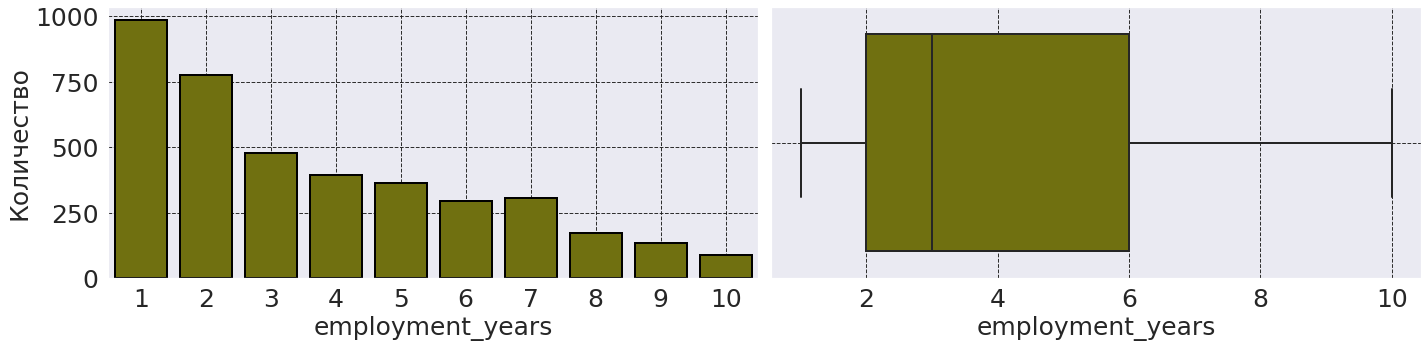

**p-value** = 0.000e+00, следовательно распределение **ненормальное**

<center>**************************************************************************</center>

<center><strong>supervisor_evaluation</strong></center>

count    4000.00
mean        3.47
std         1.00
min         1.00
25%         3.00
50%         4.00
75%         4.00
max         5.00
Name: supervisor_evaluation, dtype: float64

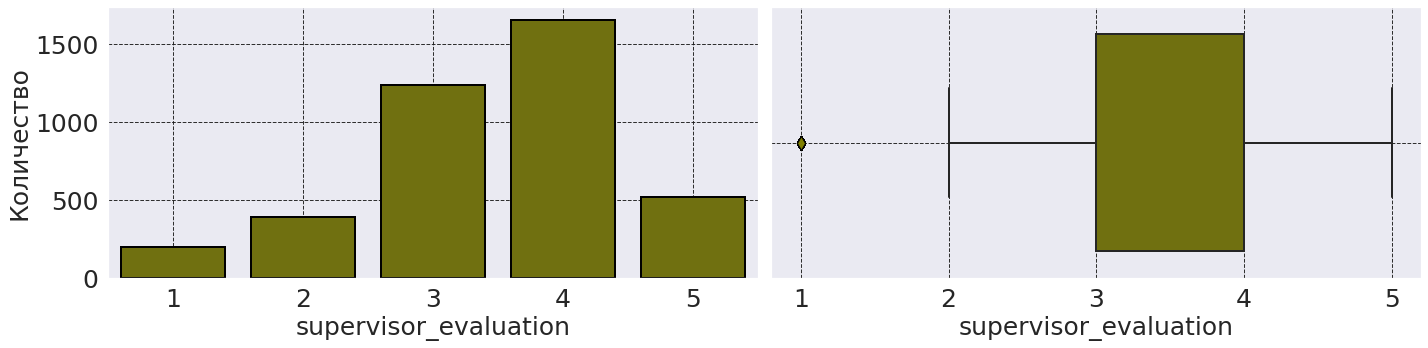

**p-value** = 0.000e+00, следовательно распределение **ненормальное**

<center>**************************************************************************</center>

<center><strong>salary</strong></center>

count     4000.00
mean     33805.80
std      15152.42
min      12000.00
25%      22800.00
50%      30000.00
75%      43200.00
max      96000.00
Name: salary, dtype: float64

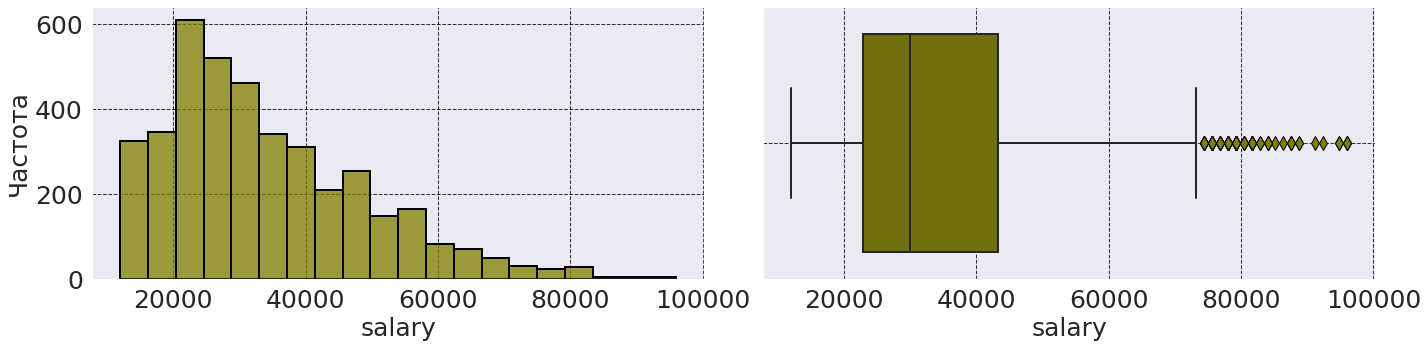

**p-value** = 1.089e-39, следовательно распределение **ненормальное**

<center>**************************************************************************</center>

In [ ]:
analysis_num_features(train_quit)

<center>Визуализация признаков для <strong>train_quit</strong></center>

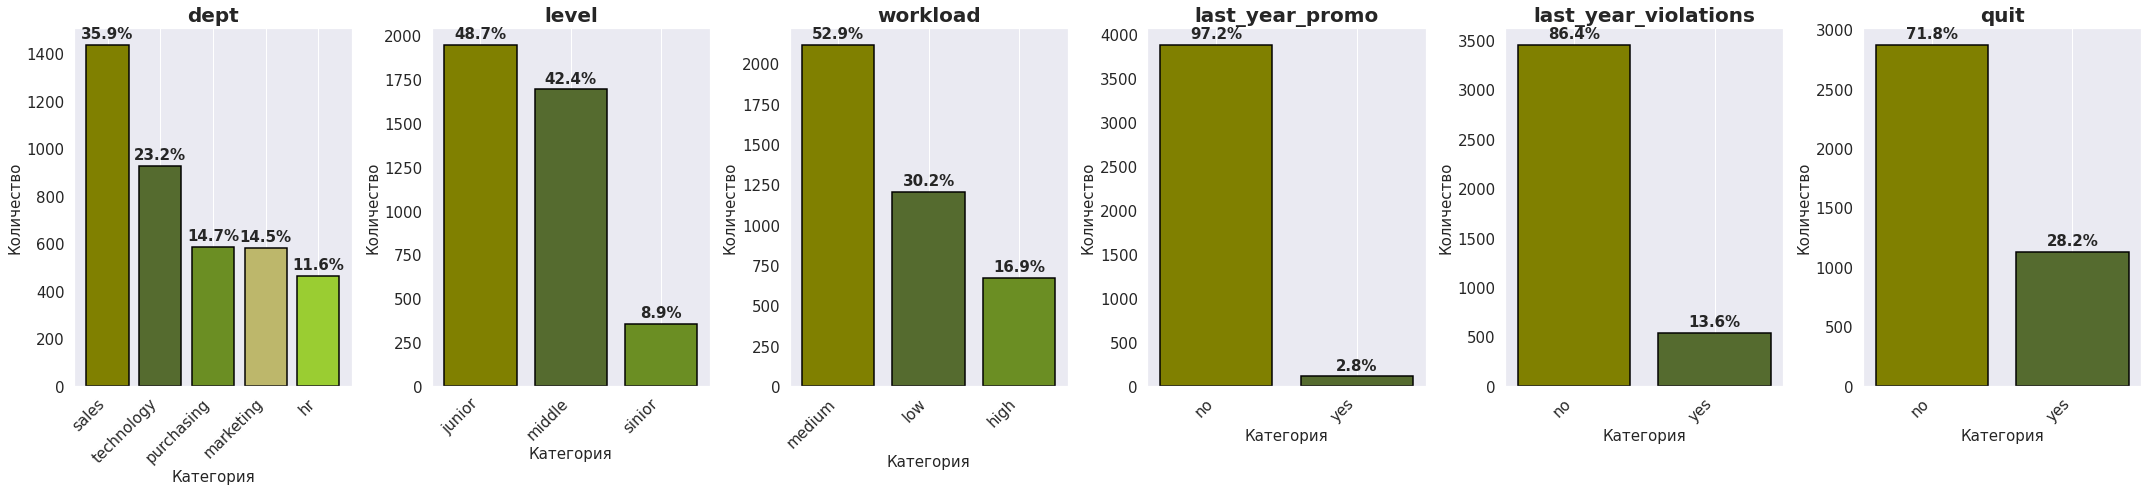

In [ ]:
bar_chart(train_quit, train_quit.select_dtypes(include='object').columns.tolist(), 'train_quit')

<center>Визуализация признаков для <strong>test_target_quit</strong></center>

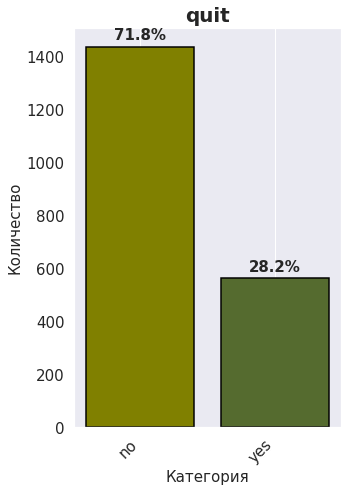

In [ ]:
bar_chart(test_target_quit, test_target_quit.select_dtypes(include='object').columns.tolist(), 'test_target_quit')

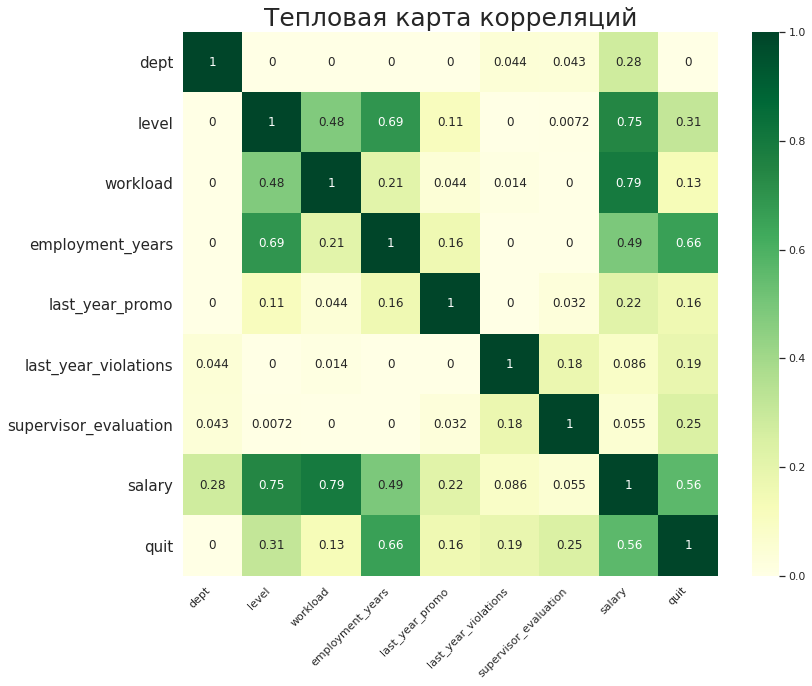

In [ ]:
plt.figure(figsize=(12,10))
heatmap = sns.heatmap(
                train_quit[train_quit.columns[train_quit.columns != 'id']]\
                [list(train_quit[train_quit.columns[train.columns != 'id']].columns)]\
                .phik_matrix(interval_cols = [ 'salary', 'job_satisfaction_rate']),
                annot=True,
                cmap='YlGn'
                )

heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=15)

plt.title('Тепловая карта корреляций', fontsize=25)
plt.show()

Анализ показал:  
- Одноименные признаки имеют идентичную визуализацию, рассматривать из повторно смысла не имеет.
- Данные тестовой и тренировочной выборок одинаково распределены, что говорит разделение проведено правильно, с учетом распределений признаков;
- Чуть больше 75% сотрудников из предоставленных данных уволены из компании.
- Целевой признак неплохо коррелирует с заработной платой и стажем работы.

### Портрет «уволившегося сотрудника»

In [ ]:
retired_employees = train_quit[train_quit['quit'] == 'yes']
retired_employees.drop('id', axis=1).describe().round(2)

,employment_years,supervisor_evaluation,salary
count,1128.00,1128.00,1128.00
mean,1.84,3.05,23885.11
std,1.27,0.97,9351.60
min,1.00,1.00,12000.00
25%,1.00,3.00,16800.00
50%,1.00,3.00,22800.00
75%,2.00,4.00,27600.00
max,10.00,5.00,79200.00


<center>Визуализация признаков для <strong>уволившихся сотрудников</strong></center>

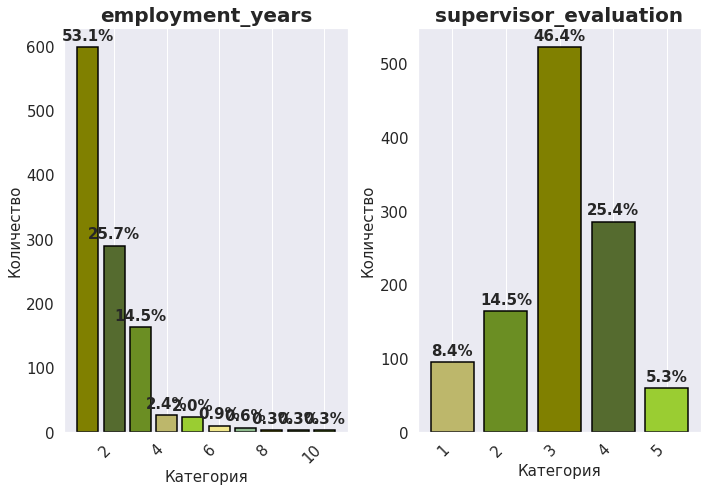

In [ ]:
bar_chart(retired_employees, ['employment_years', 'supervisor_evaluation'], 'уволившихся сотрудников')

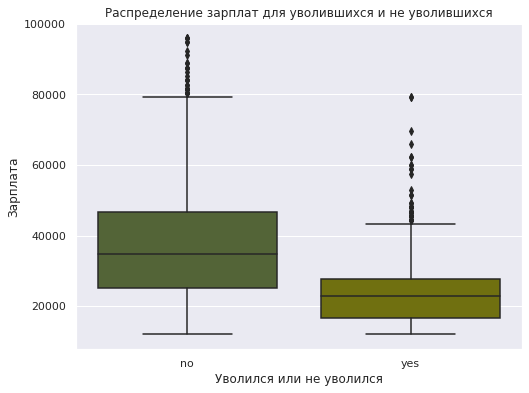

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='quit', y='salary', data=train_quit, palette=['#556B2F', 'olive'])
plt.title('Распределение зарплат для уволившихся и не уволившихся')
plt.xlabel('Уволился или не уволился')
plt.ylabel('Зарплата')
plt.show()

<center>Визуализация признаков для <strong>уволившихся сотрудников</strong></center>

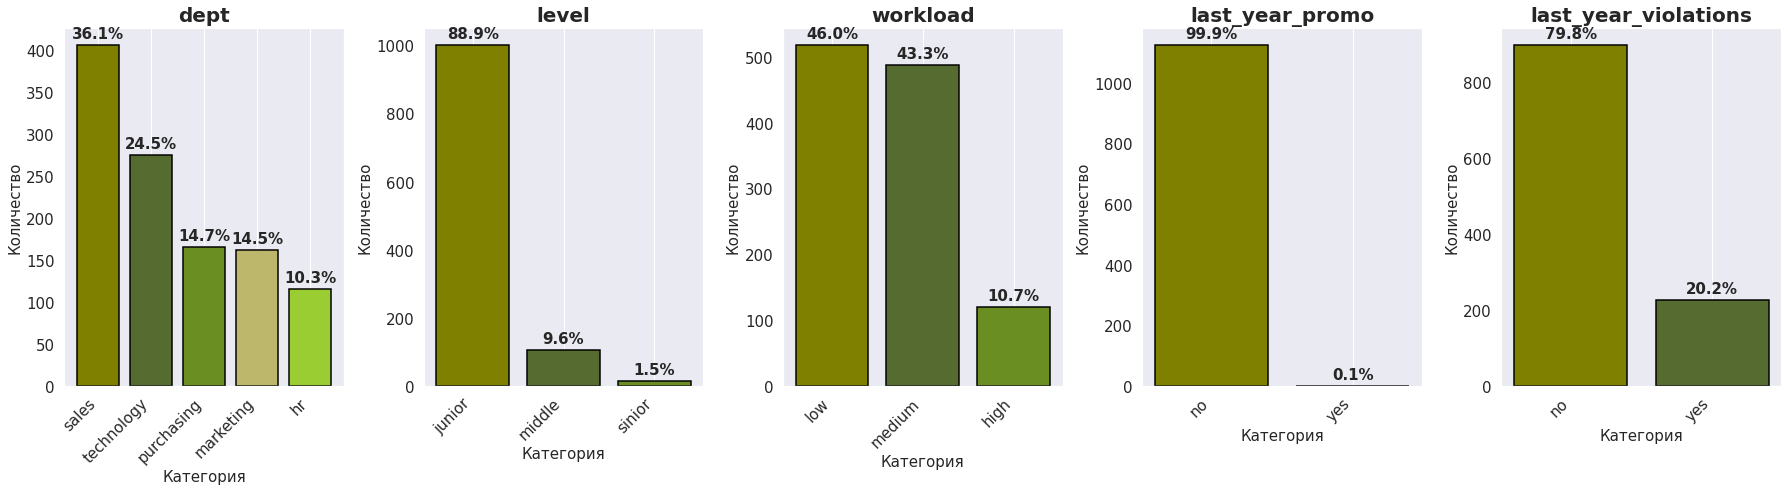

In [ ]:
bar_chart(retired_employees,
          ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations'],
          'уволившихся сотрудников')

Из исследования можно полчить следующий портрет «уволившегося сотрудника»:  
- Стаж работы зачастую от 1 до 2 лет;
- Оценка качества работы 3 или 4;
- Медианная зарплата 22800;
- Теряющий наибольшее число сотрудников отдел - продажи;
- Колоссальная доля уволившихся это junior без повышения не нарушавшие трудовой договор;
- Касательно нагрузки она в равных долях распределена между низкой и средней.

### Зависимость между job_satisfaction_rate и quit

In [ ]:
df_job_satisfaction = test_x.copy()
df_job_satisfaction = df_job_satisfaction.merge(test_target_quit, on='id')
df_job_satisfaction

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.72,no
2,467458,sales,middle,low,5,no,no,4,19200,0.64,no
3,418655,sales,middle,low,6,no,no,4,19200,0.60,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.75,no
...,...,...,...,...,...,...,...,...,...,...,...
1995,393147,marketing,junior,low,3,no,no,3,20400,0.56,yes
1996,109582,technology,middle,low,3,no,no,2,21600,0.14,yes
1997,305653,technology,junior,low,1,no,no,3,14400,0.11,yes
1998,160233,technology,middle,low,8,no,no,1,32400,0.43,no


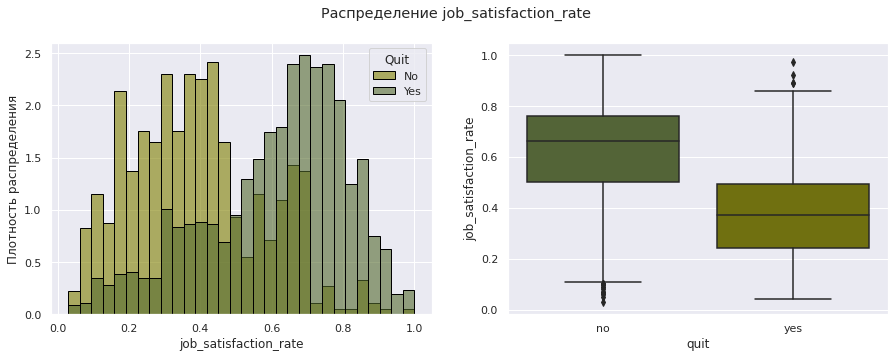

In [ ]:
sns.set(rc={"figure.figsize": (15, 5)})

fig,axes=plt.subplots(1,2)

sns.histplot(
    data=df_job_satisfaction,
    x='job_satisfaction_rate',
    bins=30,
    hue='quit',
    ax=axes[0],
    palette=['#556B2F', 'olive'],
    edgecolor='black',
    legend=True,
    stat='density',
    common_norm=False,
    alpha=0.6
)
axes[0].set(ylabel='Плотность распределения', xlabel='job_satisfaction_rate')
axes[0].legend(title='Quit', labels=['No', 'Yes'], loc='upper right')

sns.boxplot(
    data=df_job_satisfaction,
    y='job_satisfaction_rate',
    x='quit',
    ax=axes[1],
    palette=['#556B2F', 'olive'],
    dodge=False
    )
axes[1].set(ylabel='job_satisfaction_rate')

plt.suptitle(f'Распределение job_satisfaction_rate')
plt.show()

Сформулируем гипотезы:  
**Нулевая гипотеза Н0:** средние уровни удовлетворенности уволившихся и оставшихся сотрудников равны.  
**Альтернативная гипотеза Н1:** средние уровни удовлетворенности уволившихся и оставшихся сотрудников не равны.

Поскольку данные выборки независимы, то для проверки гипотезы о равенстве среднего двух генеральных совокупностей используем метод st.ttest_ind

In [ ]:
alpha = 0.05

results = st.ttest_ind(df_job_satisfaction.query('quit == "no"')['job_satisfaction_rate'],
                       df_job_satisfaction.query('quit == "yes"')['job_satisfaction_rate'])

print(
    'Средний уровень удовлетворённости уволившихся сотрудников:',
    round(df_job_satisfaction.query('quit == "yes"')['job_satisfaction_rate'].mean(), 2)
        )
print(
    'Средний уровень удовлетворённости оставшихся сотрудников:',
    round(df_job_satisfaction.query('quit == "no"')['job_satisfaction_rate'].mean(), 2)
        )
print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средний уровень удовлетворённости уволившихся сотрудников: 0.39
Средний уровень удовлетворённости оставшихся сотрудников: 0.61
p-значение: 1.231122066517193e-104
Отвергаем нулевую гипотезу


Нулевая гипотеза отвергнута, значит мы можем утвеждать,что уровень удовлетворённости сотрудника влияет на то, уволится ли он.  
Соответственно мы можем добавить этот признак к остальным.

## Шаг 4. Добавление нового входного признака  

In [ ]:
train_quit['job_satisfaction_rate'] = grid_search.predict(train_quit)
train_quit.head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.657619
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.815938
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.360435
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.380000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000
5,699916,sales,junior,low,1,no,yes,3,18000,yes,0.190000
6,417070,technology,middle,medium,8,no,no,2,44400,no,0.385625
7,165489,sales,middle,low,4,no,no,5,19200,no,0.470000
8,996399,marketing,middle,low,7,no,no,4,25200,no,0.812340
9,613206,technology,middle,medium,2,no,no,3,45600,yes,0.355000


In [ ]:
test_x_1 = test_features.copy()
test_x_1['job_satisfaction_rate'] = grid_search.predict(test_x_1)
test_x_1 = test_x_1.merge(test_target_quit, on='id')
test_x_1.head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.883333,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.665000,no
2,467458,sales,middle,low,5,no,no,4,19200,0.660000,no
3,418655,sales,middle,low,6,no,no,4,19200,0.666000,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.815667,no
5,429973,purchasing,middle,medium,6,no,no,3,42000,0.574478,yes
6,850699,technology,junior,medium,3,no,no,3,26400,0.370270,yes
7,500791,sales,middle,high,9,no,no,4,49200,0.670294,no
8,767867,marketing,middle,high,3,no,yes,4,62400,0.360000,no
9,937235,sales,junior,medium,1,no,yes,3,26400,0.150000,yes


## Шаг 5. Подготовка данных

In [ ]:
X_train = train_quit.drop(['quit', 'id'], axis=1)
y_train = train_quit['quit']
X_test = test_x_1.drop(['quit', 'id'], axis=1)
y_test = test_x_1['quit']

In [ ]:
le = LabelEncoder()

le.classes_ = np.array(['no', 'yes'])

y_train = le.transform(y_train)
y_test = le.transform(y_test)

cat_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = [
               'employment_years',
               'supervisor_evaluation',
               'salary',
               'job_satisfaction_rate'
              ]

#пайплан для категорианальных признаков
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))]
                   )

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium', 'high']
                           ],
         handle_unknown='use_encoded_value',
         unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ])

#пайплайны для числовых признаков
standard_pipe = Pipeline([
    ('simplerImputer_standard', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', StandardScaler())
])

# создание общего пайплайна для подготовки данных
data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, cat_columns),
    ('ord', ord_pipe, ord_columns),
    ('num', standard_pipe, num_columns)
], remainder='passthrough')

## Шаг 6. Обучение моделей

In [ ]:
# создаём итоговый пайплайн
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    'preprocessor__num__scaler': [MinMaxScaler(), StandardScaler(), 'passthrough'],
    'models': [DecisionTreeClassifier(random_state=RANDOM_STATE),
               KNeighborsClassifier(),
               LogisticRegression(random_state=RANDOM_STATE)]
}

# параметры для передачи GridSearchCV для поиска оптимальной модели
param_distributions = [
    # DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 7),
        'models__max_features': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    # KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    # LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE,
            solver='liblinear',
            penalty='l1'
        )],
        'models__C': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

In [ ]:
#поиск лучшей модели без перебора гиперпараметров
grid_1 = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_1.fit(X_train, y_train)

# выведите параметры лучшей модели
print('Лучшая модель и её параметры без перебора гиперпараметров:\n', grid_1.best_params_)
print('ROC-AUC для этой модели:', grid_1.best_score_.round(4), '\n\n')

Лучшая модель и её параметры без перебора гиперпараметров:
 {'models': LogisticRegression(random_state=42), 'preprocessor__num__scaler': StandardScaler()}
ROC-AUC для этой модели: 0.9176 




In [ ]:
#поиск лучшей модели с перебором гиперпараметров
grid_2 = GridSearchCV(
    pipe_final,
    param_grid=param_distributions,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)

#обучение модели на тренировочной выборке
grid_2.fit(X_train, y_train)
print('Лучшая модель и её параметры с перебором гиперпараметров:\n', grid_2.best_params_)
print('Метрика ROC-AUC для этой модели:', grid_2.best_score_.round(4))

Лучшая модель и её параметры с перебором гиперпараметров:
 {'models': DecisionTreeClassifier(random_state=42), 'models__max_depth': 6, 'models__max_features': 6, 'preprocessor__num': StandardScaler()}
Метрика ROC-AUC для этой модели: 0.9276


In [ ]:
y_pred = grid_2.predict_proba(X_test)
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_pred[:, 1]).round(4)}')

Метрика ROC-AUC на тестовой выборке: 0.9167


## Шаг 7. Вывод по задаче

- Загрузили и изучили данные.  
- Убедились в том, что предобработка не требуется.  
- Произвели исследовательский анализ и визуализацию признаков из новых датафреймов, в ходе которого было установлено, что признаки практически идентины по расспределениям признаков из задачи 2. Так же выяснили, что чуть больше 75% сотрудников из предоставленных данных уволены из компании.
- Составили портрет уволившегося сотрудника:  
  
    - Стаж работы зачастую от 1 до 2 лет;
    - Оценка качества работы от 3 до 4;
    - Медианная зарплата 22800;
    - Теряющий наибольшее число сотрудников отдел - продажи;
    - Колоссальная доля уволившихся это junior без повышения и не нарушавшие трудовой договор;
    - Нагрузка невысокая, низкая и средняя в почти равных долях.  
      
- Проверили зависимость между job_satisfaction_rate и quit. Выяснилось, что зависимость есть.
- Подготовили данные.
- Обучили модель и получили следующий результат:  
  
  Лучшей оказалась модель **DecisionTreeClassifier(random_state=42)** с метрикой **ROC_AUC = 0.9276** на тренировочной выборке и **ROC-AUC = 0.9167** на тестовой, что удовлетворяет условиям задачи ROC_AUC >= 0.91.

# Общий вывод

В ходе проекта были проанализированы данные о сотрудниках компании "Работа с заботой" и были решены 2 задачи:  
- Поиск лучшей модели для предсказания удовлетворенности сотрудника.
- Поиск лучшей модели для предсказания его возможного ухода из компании.  
  
  
  <h2 style="font-weight: bold; font-size: 1.2em;">Результатом решения первой задачи стала модель:</h2>  
  
  **_DecisionTreeRegressor(random_state=42) с метрикой SMAPE = 14.39 на тестовой выборке, что соответствует критерию успеха, установленного в задаче(≤ 15)._**
  
  <h2 style="font-weight: bold; font-size: 1.2em;">Результатом решения второй задачи стали:</h2>
  
  **_Портрет уволившегося сотрудника:_**  
    * Стаж работы зачастую от 1 до 2 лет;  
    * Оценка качества работы от 3 до 4;  
    * Медианная зарплата 22800;  
    * Теряющий наибольшее число сотрудников отдел - продажи;  
    * Колоссальная доля уволившихся это junior без повышения и не нарушавшие трудовой договор;  
    * Нагрузка невысокая, низкая и средняя в почти равных долях.  
    
  **_Модель DecisionTreeClassifier(random_state=42) с метрикой ROC_AUC = 0.9276 на тренировочной выборке и ROC-AUC = 0.9167 на тестовой, что удовлетворяет условиям задачи ROC_AUC >= 0.91._**

<div class="alert alert-success">
<b><strong>Рекомендации</strong><br></b>
Исходя из полученных данных после проделанной работы, можно дать следующие рекомендации бизнесу: повысить зарплату или провести повышение среди junior сотрудников. При этом стоит уделить большее внимание отделу продаж.
</div>